# Démo — inspection de défauts d'acier (MAE)
Reconstruction et classification du défaut. Backend torch, exécuté sur CPU.

In [3]:
import torch, numpy as np, matplotlib.pyplot as plt
import mae as M, train as T
M.use("cpu", torch.float32)
CFG = dict(img=96, P=8, C=3, D=128, enc_depth=6, enc_heads=4,
           dec_dim=64, dec_depth=2, dec_heads=4, mlp_ratio=4, mask_ratio=0.75, norm_pix=True)
model = M.load_params(M.MAE(CFG), "results/neu_model.npz")
probe = np.load("results/neu_probe.npz", allow_pickle=True)
names = [str(s) for s in probe["names"]]
Xtr, ytr, Xte, yte, classes = T.load_neu()
idx = [np.where(yte == c)[0][0] for c in range(6)]
imgs, ytrue = Xte[idx], yte[idx]
print("modèle + sonde chargés, 6 défauts :", names)

modèle + sonde chargés, 6 défauts : ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']


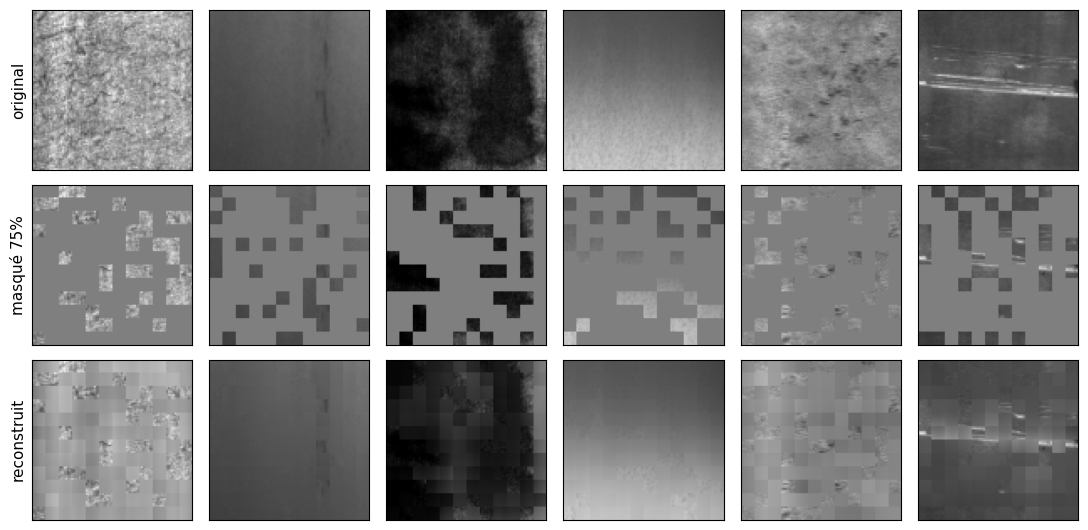

In [4]:
# ce que le MAE voit (25%) et ce qu'il reconstruit
orig, masked, recon = T.make_reconstruction(model, imgs, mask_ratio=0.75, seed=0)
fig, ax = plt.subplots(3, 6, figsize=(11, 5.4))
for j in range(6):
    for i, (im, lab) in enumerate([(orig, "original"), (masked, "masqué 75%"), (recon, "reconstruit")]):
        ax[i, j].imshow(im[j], cmap="gray"); ax[i, j].set_xticks([]); ax[i, j].set_yticks([])
        if j == 0: ax[i, 0].set_ylabel(lab, fontsize=11)
plt.tight_layout(); plt.show()

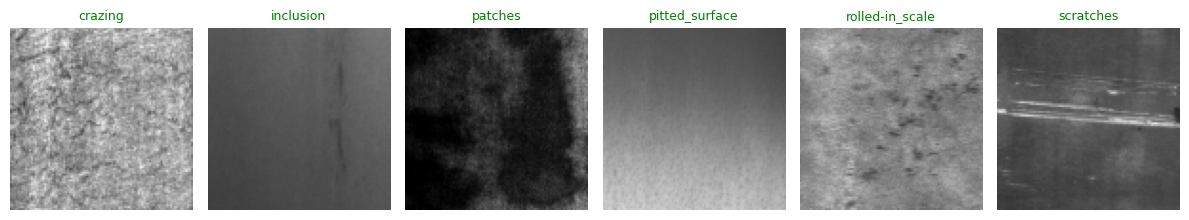

In [5]:
# classification : encodeur gelé -> features -> sonde linéaire
feat = model.features(M._t(imgs)).detach().cpu().numpy()
feat = (feat - probe["mu"]) / probe["sd"]
pred = (feat @ probe["W"] + probe["b"]).argmax(1)
fig, ax = plt.subplots(1, 6, figsize=(12, 2.4))
for j in range(6):
    ok = pred[j] == ytrue[j]
    ax[j].imshow(imgs[j], cmap="gray"); ax[j].axis("off")
    ax[j].set_title(names[pred[j]] if ok else f"{names[pred[j]]}\n(vrai: {names[ytrue[j]]})",
                    color="green" if ok else "red", fontsize=9)
plt.tight_layout(); plt.show()